# DiD

In [6]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 8, Finished, Available, Finished, False)

In [7]:
%run ./did_model

StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 9, Finished, Available, Finished, True)

In [8]:
# Settings
match_method = "calendar2_1year"
outcome_col = "top3_mean_consumption"

EVENT_WINDOW = (-12, 12)
REFERENCE_EVENT_TIME = -1

StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 10, Finished, Available, Finished, False)

In [9]:
# Read data
matches = pd.read_parquet(
    f"/lakehouse/default/Files/output/matching_high/{match_method}/matches"
)

month_result = pd.read_parquet(
    "/lakehouse/default/Files/month_data"
)

StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 11, Finished, Available, Finished, False)

StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 12, Finished, Available, Finished, False)

Running cohort 2025-03, treated households = 625


Running cohort 2025-04, treated households = 334


Running cohort 2025-05, treated households = 140


Running cohort 2025-06, treated households = 125


...

Running cohort 2025-08, treated households = 40


Running cohort 2025-09, treated households = 49


Running cohort 2025-10, treated households = 50


Running cohort 2025-11, treated households = 148


Running cohort 2025-12, treated households = 121


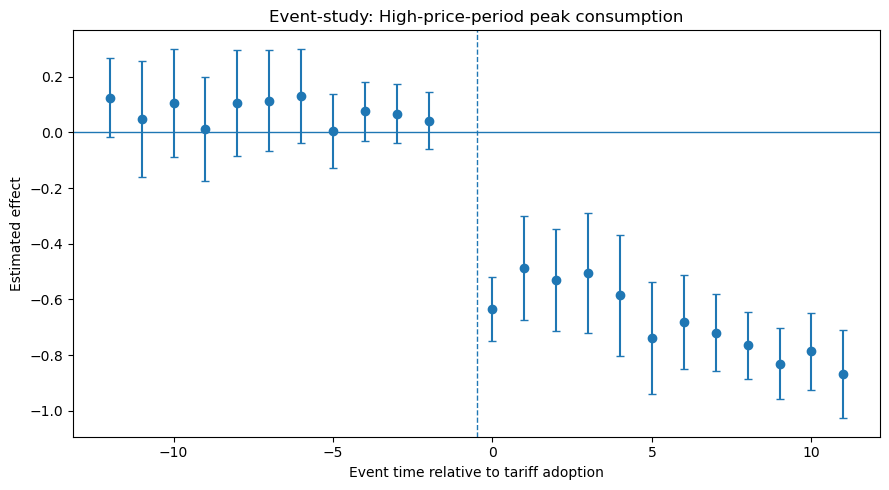

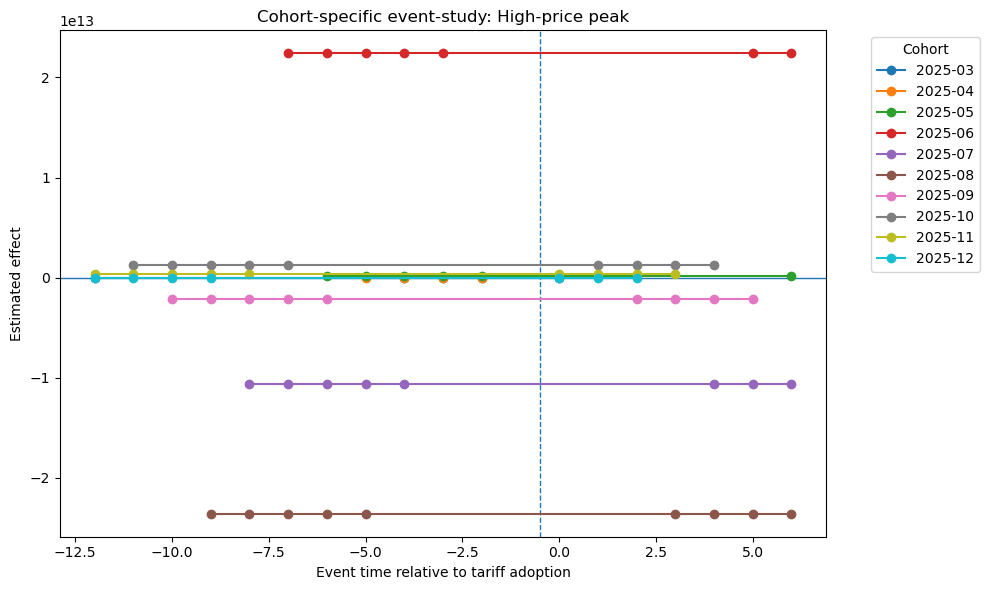

In [10]:
price_value = "high"

df_high = prepare_price_panel(
    month_result=month_result,
    price_value=price_value,
    outcome_col=outcome_col
)

matched_high = build_matched_panel(
    matches=matches,
    month_result=df_high,
    outcome_col=outcome_col
)

model_high, result_high = run_basic_did_one(
    matched_high,
    outcome_col=outcome_col,
    cluster_col="aID"
)

cohort_basic_models, cohort_basic_results_df = run_basic_did_by_cohort(
    df=matched_high,
    outcome_col=outcome_col,
    min_treated=30,
    cluster_col="aID"
)

event_model_high, event_results_high = run_event_study_one(
    matched_high,
    outcome_col=outcome_col,
    event_window=EVENT_WINDOW,
    reference=REFERENCE_EVENT_TIME,
    cluster_col="aID"
)

cohort_event_models, cohort_event_results_df = run_event_study_by_cohort(
    df=matched_high,
    outcome_col=outcome_col,
    event_window=(-12, 6),
    reference=-1,
    min_treated=30,
    cluster_col="aID"
)

plot_event_study(
    event_results_high,
    outcome_col=outcome_col,
    title="Event-study: High-price-period peak consumption"
)

plot_event_study_by_cohort(
    cohort_event_results_df,
    outcome_col=outcome_col,
    title="Cohort-specific event-study: High-price peak"
)

StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 13, Finished, Available, Finished, False)

Running cohort 2025-03, treated households = 625


Running cohort 2025-04, treated households = 334


Running cohort 2025-05, treated households = 140


Running cohort 2025-06, treated households = 125


...

Running cohort 2025-08, treated households = 40


Running cohort 2025-09, treated households = 49


Running cohort 2025-10, treated households = 50


Running cohort 2025-11, treated households = 148


Running cohort 2025-12, treated households = 121


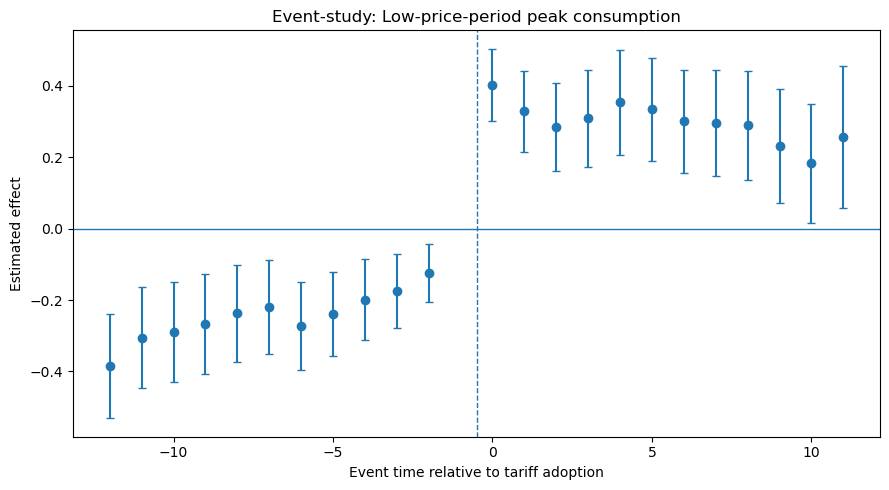

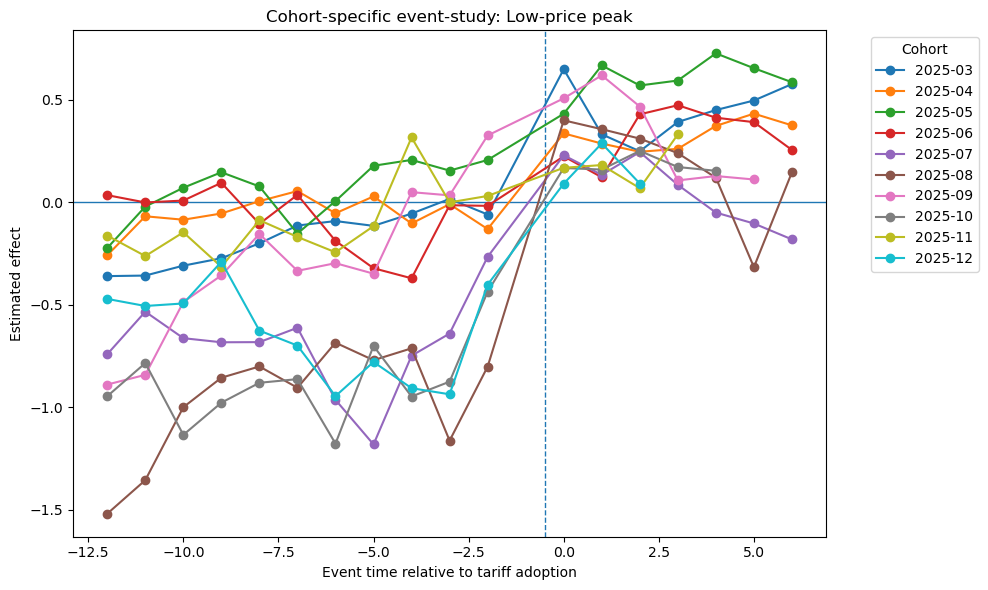

In [11]:
# ============================================================
# LOW PRICE PERIOD
# ============================================================

price_value = "low"

df_low = prepare_price_panel(
    month_result=month_result,
    price_value=price_value,
    outcome_col=outcome_col
)

matched_low = build_matched_panel(
    matches=matches,
    month_result=df_low,
    outcome_col=outcome_col
)

model_low, result_low = run_basic_did_one(
    matched_low,
    outcome_col=outcome_col,
    cluster_col="aID"
)

cohort_basic_models_low, cohort_basic_results_df_low = run_basic_did_by_cohort(
    df=matched_low,
    outcome_col=outcome_col,
    min_treated=30,
    cluster_col="aID"
)

event_model_low, event_results_low = run_event_study_one(
    matched_low,
    outcome_col=outcome_col,
    event_window=EVENT_WINDOW,
    reference=REFERENCE_EVENT_TIME,
    cluster_col="aID"
)

cohort_event_models_low, cohort_event_results_df_low = run_event_study_by_cohort(
    df=matched_low,
    outcome_col=outcome_col,
    event_window=(-12, 6),
    reference=-1,
    min_treated=30,
    cluster_col="aID"
)

plot_event_study(
    event_results_low,
    outcome_col=outcome_col,
    title="Event-study: Low-price-period peak consumption"
)

plot_event_study_by_cohort(
    cohort_event_results_df_low,
    outcome_col=outcome_col,
    title="Cohort-specific event-study: Low-price peak"
)

StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 14, Finished, Available, Finished, False)

Running cohort 2025-03, treated households = 625


Running cohort 2025-04, treated households = 334


Running cohort 2025-05, treated households = 140


Running cohort 2025-06, treated households = 125


...

Running cohort 2025-08, treated households = 40


Running cohort 2025-09, treated households = 49


Running cohort 2025-10, treated households = 50


Running cohort 2025-11, treated households = 148


Running cohort 2025-12, treated households = 121


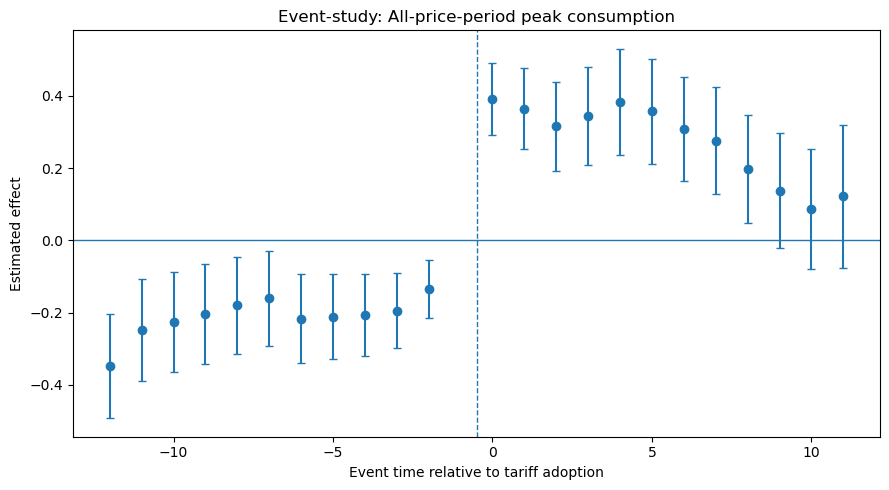

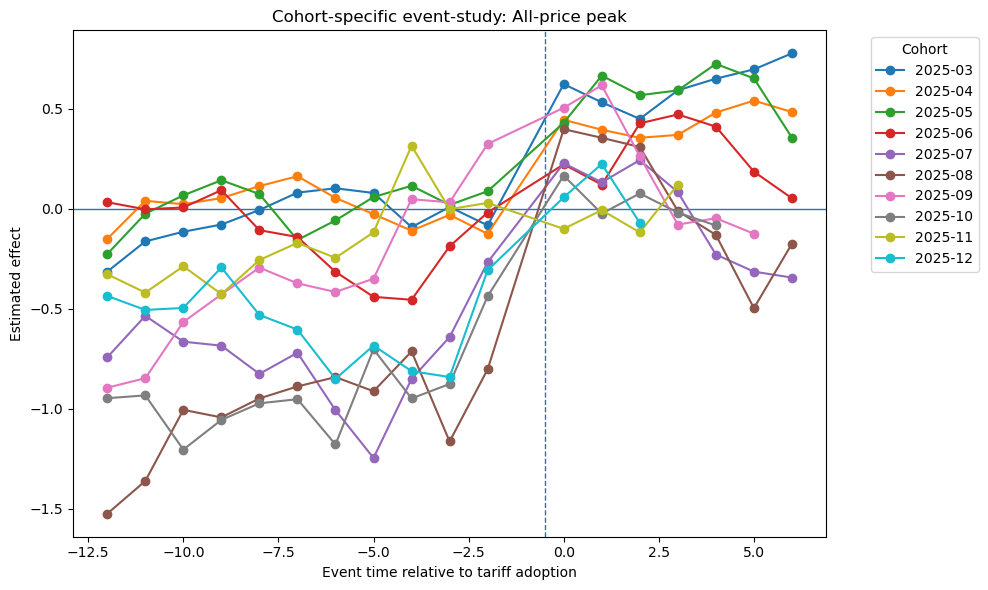

In [12]:
# ============================================================
# ALL PRICE PERIOD
# ============================================================

price_value = "all"

df_all = prepare_price_panel(
    month_result=month_result,
    price_value=price_value,
    outcome_col=outcome_col
)

matched_all = build_matched_panel(
    matches=matches,
    month_result=df_all,
    outcome_col=outcome_col
)

model_all, result_all = run_basic_did_one(
    matched_all,
    outcome_col=outcome_col,
    cluster_col="aID"
)

cohort_basic_models_all, cohort_basic_results_df_all = run_basic_did_by_cohort(
    df=matched_all,
    outcome_col=outcome_col,
    min_treated=30,
    cluster_col="aID"
)

event_model_all, event_results_all = run_event_study_one(
    matched_all,
    outcome_col=outcome_col,
    event_window=EVENT_WINDOW,
    reference=REFERENCE_EVENT_TIME,
    cluster_col="aID"
)

cohort_event_models_all, cohort_event_results_df_all = run_event_study_by_cohort(
    df=matched_all,
    outcome_col=outcome_col,
    event_window=(-12, 6),
    reference=-1,
    min_treated=30,
    cluster_col="aID"
)

plot_event_study(
    event_results_all,
    outcome_col=outcome_col,
    title="Event-study: All-price-period peak consumption"
)

plot_event_study_by_cohort(
    cohort_event_results_df_all,
    outcome_col=outcome_col,
    title="Cohort-specific event-study: All-price peak"
)

In [13]:
# ============================================================
# HIGH PRICE PERIOD
# ============================================================

print_result_table(
    result_high,
    title="HIGH PRICE PERIOD — Basic DiD"
)

print_result_table(
    cohort_basic_results_df,
    title="HIGH PRICE PERIOD — Cohort-specific DiD"
)

print_result_table(
    event_results_high,
    title="HIGH PRICE PERIOD — Event-study Dynamic Effects"
)

print_result_table(
    cohort_event_results_df,
    title="HIGH PRICE PERIOD — Cohort-specific Event-study"
)



StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 15, Finished, Available, Finished, False)


HIGH PRICE PERIOD — Basic DiD
              outcome    coef  std_error  p_value  ci_lower  ci_upper  n_obs  n_entities
top3_mean_consumption -0.8335     0.0396      0.0   -0.9112   -0.7558 166773        9875

HIGH PRICE PERIOD — Cohort-specific DiD
 cohort               outcome    coef  std_error  p_value  ci_lower  ci_upper  n_treated  n_periods  n_obs  n_entities
2025-03 top3_mean_consumption -0.9117     0.0633   0.0000   -1.0358   -0.7876        625          5  60007        3549
2025-04 top3_mean_consumption -0.6677     0.0836   0.0000   -0.8316   -0.5037        334          4  33157        1960
2025-05 top3_mean_consumption -0.9542     0.1459   0.0000   -1.2402   -0.6682        140          4  13879         824
2025-06 top3_mean_consumption -0.8489     0.1527   0.0000   -1.1483   -0.5496        125          4  12641         746
2025-07 top3_mean_consumption -0.9847     0.2325   0.0000   -1.4405   -0.5290         64          4   6388         379
2025-08 top3_mean_consumption -0.972

In [15]:

# ============================================================
# LOW PRICE PERIOD
# ============================================================

print_result_table(
    result_low,
    title="LOW PRICE PERIOD — Basic DiD"
)

print_result_table(
    cohort_basic_results_df_low,
    title="LOW PRICE PERIOD — Cohort-specific DiD"
)

print_result_table(
    event_results_low,
    title="LOW PRICE PERIOD — Event-study Dynamic Effects"
)

print_result_table(
    cohort_event_results_df_low,
    title="LOW PRICE PERIOD — Cohort-specific Event-study"
)

StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 17, Finished, Available, Finished, False)


LOW PRICE PERIOD — Basic DiD
              outcome   coef  std_error  p_value  ci_lower  ci_upper  n_obs  n_entities
top3_mean_consumption 0.6469      0.057      0.0    0.5352    0.7587 372645        9875

LOW PRICE PERIOD — Cohort-specific DiD
 cohort               outcome   coef  std_error  p_value  ci_lower  ci_upper  n_treated  n_periods  n_obs  n_entities
2025-03 top3_mean_consumption 0.7844     0.0920   0.0000    0.6042    0.9647        625         12 134082        3549
2025-04 top3_mean_consumption 0.5631     0.1209   0.0000    0.3261    0.8002        334         11  74080        1960
2025-05 top3_mean_consumption 0.6896     0.2157   0.0014    0.2667    1.1124        140         10  31022         824
2025-06 top3_mean_consumption 0.3865     0.2118   0.0681   -0.0287    0.8017        125          9  28239         746
2025-07 top3_mean_consumption 0.7777     0.3291   0.0181    0.1326    1.4228         64          8  14275         379
2025-08 top3_mean_consumption 1.4240     0.332

In [14]:


# ============================================================
# ALL PRICE PERIOD
# ============================================================

print_result_table(
    result_all,
    title="ALL PRICE PERIOD — Basic DiD"
)

print_result_table(
    cohort_basic_results_df_all,
    title="ALL PRICE PERIOD — Cohort-specific DiD"
)

print_result_table(
    event_results_all,
    title="ALL PRICE PERIOD — Event-study Dynamic Effects"
)

print_result_table(
    cohort_event_results_df_all,
    title="ALL PRICE PERIOD — Cohort-specific Event-study"
)
     

StatementMeta(, 2ce1220c-d2e0-4b69-92a0-98fcac1e7902, 16, Finished, Available, Finished, False)


ALL PRICE PERIOD — Basic DiD
              outcome   coef  std_error  p_value  ci_lower  ci_upper  n_obs  n_entities
top3_mean_consumption 0.6158     0.0568      0.0    0.5045    0.7271 372645        9875

ALL PRICE PERIOD — Cohort-specific DiD
 cohort               outcome   coef  std_error  p_value  ci_lower  ci_upper  n_treated  n_periods  n_obs  n_entities
2025-03 top3_mean_consumption 0.7687     0.0916   0.0000    0.5893    0.9482        625         12 134082        3549
2025-04 top3_mean_consumption 0.5457     0.1203   0.0000    0.3099    0.7816        334         11  74080        1960
2025-05 top3_mean_consumption 0.6484     0.2138   0.0024    0.2294    1.0673        140         10  31022         824
2025-06 top3_mean_consumption 0.3499     0.2116   0.0982   -0.0648    0.7646        125          9  28239         746
2025-07 top3_mean_consumption 0.7040     0.3277   0.0317    0.0617    1.3463         64          8  14275         379
2025-08 top3_mean_consumption 1.3166     0.328